# Data Audit: Model Predictions vs Manual Ground Truth

This notebook audits prediction quality, fairness by skin tone, and Angry-specific misclassification behavior.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Always resolve paths relative to project root regardless of where notebook is run from.
if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(PROJECT_ROOT)
print("Working directory set to:", Path.cwd())

plt.style.use("default")

ASSET_DIR = Path("reports/assets")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_PATH = Path("data/1408-1010-intermediate/manual_labels_export.csv")
LANDMARK_PATH = Path("data/1408-1010-intermediate/landmark_features.csv")

print("Manual path exists:", MANUAL_PATH.exists())
print("Landmark path exists:", LANDMARK_PATH.exists())
print("Assets dir:", ASSET_DIR.resolve())

Working directory set to: /Users/MAC/Projects/FER-Dataset
Manual path exists: True
Landmark path exists: True
Assets dir: /Users/MAC/Projects/FER-Dataset/reports/assets


## 1. Data Loading & Merge

In [2]:
manual_df = pd.read_csv(MANUAL_PATH)
landmark_df = pd.read_csv(LANDMARK_PATH)

# Normalize core labels to one taxonomy.
label_map = {
    "Anger": "Angry",
    "Happiness": "Happy",
    "Sadness": "Sad",
}

manual_df["gt_label"] = manual_df["gt_label"].astype(str).str.strip()
manual_df["model_label"] = manual_df["model_label"].astype(str).str.strip().replace(label_map)

landmark_df = landmark_df.rename(columns={"face_filename": "filename"})
if "label" in landmark_df.columns:
    landmark_df["label"] = landmark_df["label"].astype(str).str.strip().replace(label_map)

audit_df = manual_df.merge(
    landmark_df,
    on="filename",
    how="left",
    suffixes=("_manual", "_landmark"),
)

# Prefer skin-tone and luminance from landmark features when available.
if "skin_tone" in audit_df.columns:
    audit_df["skin_tone"] = audit_df["skin_tone"].astype(str).str.strip()
else:
    audit_df["skin_tone"] = "Unknown"

if "L_weighted" not in audit_df.columns:
    audit_df["L_weighted"] = np.nan

print("manual_df shape:", manual_df.shape)
print("landmark_df shape:", landmark_df.shape)
print("audit_df shape:", audit_df.shape)
display(audit_df.head())

manual_df shape: (227, 6)
landmark_df shape: (85, 10)
audit_df shape: (227, 15)


,filename,gt_label,model_label,confidence,notes,labeled_at,dataset_filename,label,skin_tone,L_weighted,brow_lowering_distance,lip_corner_distance,mouth_openness,inter_ocular_distance,iod_px
0,frame_000008_face01.jpg,Neutral,Fear,0.364011,NaN,2026-08-14T17:30:50.335Z,img_000001.jpg,Fear,Dark,20.162622,0.120820,0.572237,0.000989,25.126619,25.126619
1,frame_000008_face02.jpg,Neutral,Fear,0.494669,NaN,2026-08-14T17:31:44.953Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,frame_000008_face03.jpg,Neutral,Fear,0.384785,NaN,2026-08-14T17:31:47.980Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,frame_000009_face01.jpg,Ambiguous,Angry,0.410660,NaN,2026-08-14T17:32:14.629Z,img_000004.jpg,Angry,Dark,43.753909,0.158391,0.529607,0.000691,23.858406,23.858406
4,frame_000009_face02.jpg,Neutral,Fear,0.339235,NaN,2026-08-14T17:32:21.113Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Overall Accuracy

In [3]:
valid = audit_df[["gt_label", "model_label"]].dropna().copy()
valid = valid[(valid["gt_label"] != "") & (valid["model_label"] != "")]

overall_accuracy = (valid["gt_label"] == valid["model_label"]).mean()
error_rate = 1.0 - overall_accuracy

print(f"Overall accuracy: {overall_accuracy:.4f}")
print(f"Error rate: {error_rate:.4f}")

Overall accuracy: 0.2247
Error rate: 0.7753


## 3. Confusion Matrix

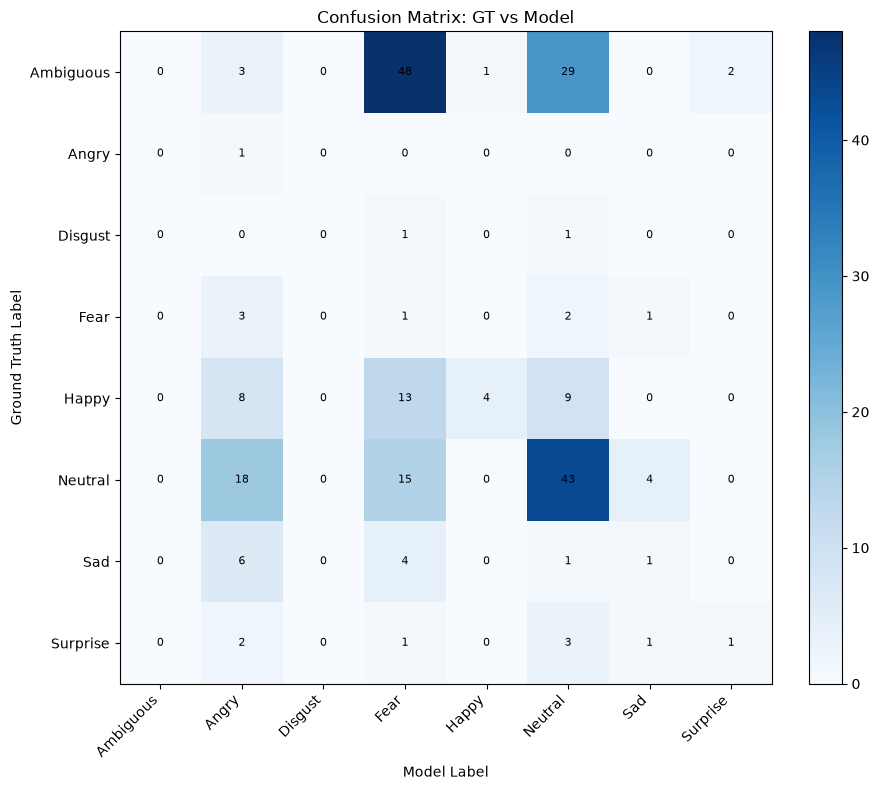

Most often misclassified as Angry (GT class): Neutral
Count: 18
Saved: reports/assets/audit_confusion_matrix.png


In [4]:
labels = sorted(set(valid["gt_label"].unique()).union(set(valid["model_label"].unique())))
cm = pd.crosstab(valid["gt_label"], valid["model_label"], rownames=["GT Label"], colnames=["Model Label"], dropna=False)
cm = cm.reindex(index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)
ax.set_xlabel("Model Label")
ax.set_ylabel("Ground Truth Label")
ax.set_title("Confusion Matrix: GT vs Model")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm.iat[i, j]
        ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = ASSET_DIR / "audit_confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

non_angry_gt = valid[valid["gt_label"] != "Angry"]
mis_as_angry = non_angry_gt[non_angry_gt["model_label"] == "Angry"]
most_mis_as_angry = None
most_mis_as_angry_count = 0
if not mis_as_angry.empty:
    vc = mis_as_angry["gt_label"].value_counts()
    most_mis_as_angry = vc.idxmax()
    most_mis_as_angry_count = int(vc.max())

print("Most often misclassified as Angry (GT class):", most_mis_as_angry)
print("Count:", most_mis_as_angry_count)
print("Saved:", cm_path)

## 4. Per Skin-Tone Accuracy

Accuracy by skin_tone:
skin_tone
Dark           0.440000
Medium-Dark    0.142857
dtype: float64
Fairness gap (max-min): 0.2971


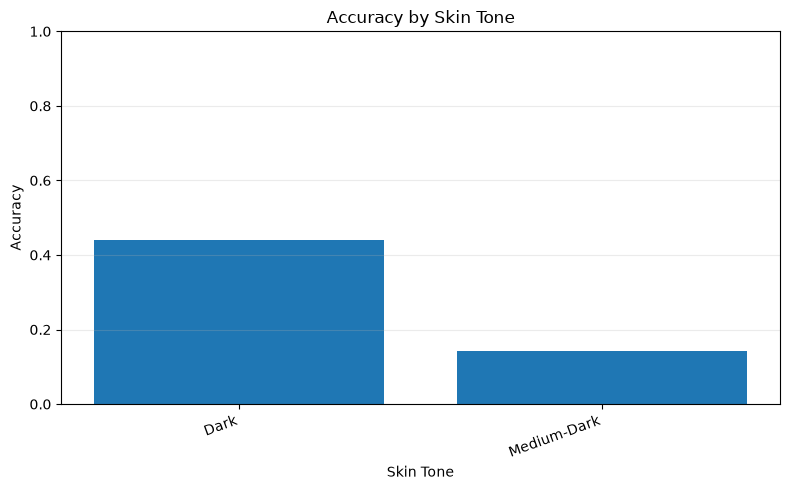

Saved: reports/assets/audit_accuracy_by_skin_tone.png


In [5]:
skin_df = audit_df.dropna(subset=["skin_tone", "gt_label", "model_label"]).copy()
skin_df = skin_df[(skin_df["skin_tone"] != "") & (skin_df["skin_tone"] != "Unknown")]

skin_acc = skin_df.groupby("skin_tone").apply(lambda g: (g["gt_label"] == g["model_label"]).mean()).sort_values(ascending=False)

if not skin_acc.empty:
    fairness_gap = float(skin_acc.max() - skin_acc.min())
else:
    fairness_gap = np.nan

print("Accuracy by skin_tone:")
print(skin_acc)
print(f"Fairness gap (max-min): {fairness_gap:.4f}" if not np.isnan(fairness_gap) else "Fairness gap: NaN")

fig, ax = plt.subplots(figsize=(8, 5))
if not skin_acc.empty:
    ax.bar(skin_acc.index, skin_acc.values)
    ax.set_ylim(0, 1)
ax.set_title("Accuracy by Skin Tone")
ax.set_xlabel("Skin Tone")
ax.set_ylabel("Accuracy")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
skin_path = ASSET_DIR / "audit_accuracy_by_skin_tone.png"
plt.savefig(skin_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", skin_path)

## 5. Angry Misclassification Deep Dive

False Angry count: 40
False Angry percentage of all samples: 0.1762

Actual GT labels among False Angry predictions:
gt_label
Neutral      18
Happy         8
Sad           6
Ambiguous     3
Fear          3
Surprise      2
Name: count, dtype: int64

False Angry by skin_tone:
skin_tone
Medium-Dark    16
NaN            13
Dark           11
Name: count, dtype: int64

False Angry rate by skin_tone:
skin_tone
Medium-Dark    0.457143
Dark           0.220000
dtype: float64


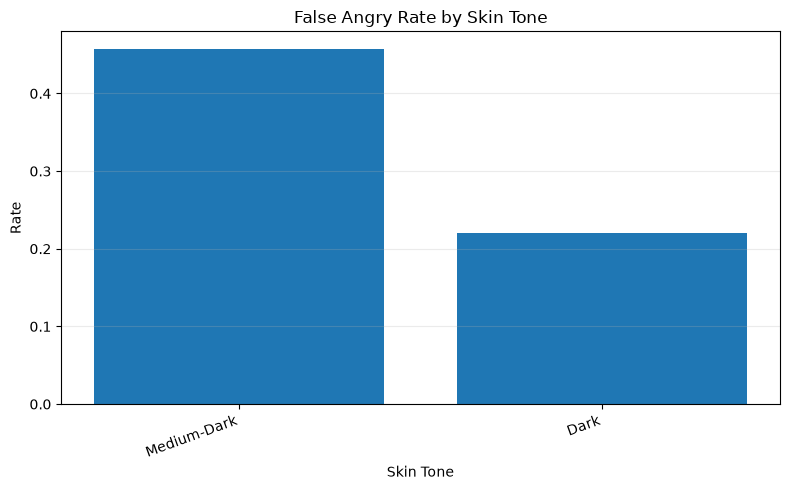

Saved: reports/assets/audit_false_angry_by_skin_tone.png


In [6]:
pred_angry = valid[valid["model_label"] == "Angry"].copy()
false_angry = pred_angry[pred_angry["gt_label"] != "Angry"].copy()

total_n = len(valid)
false_angry_n = len(false_angry)
false_angry_rate = (false_angry_n / total_n) if total_n else np.nan

print(f"False Angry count: {false_angry_n}")
print(f"False Angry percentage of all samples: {false_angry_rate:.4f}" if not np.isnan(false_angry_rate) else "False Angry percentage: NaN")

actual_breakdown = false_angry["gt_label"].value_counts()
print("\nActual GT labels among False Angry predictions:")
print(actual_breakdown)

false_angry_full = audit_df[(audit_df["model_label"] == "Angry") & (audit_df["gt_label"] != "Angry")].copy()
skin_false = false_angry_full["skin_tone"].value_counts(dropna=False)
print("\nFalse Angry by skin_tone:")
print(skin_false)

# For each skin_tone, probability of False Angry among that skin-tone subset.
subset = audit_df[(audit_df["skin_tone"].notna()) & (audit_df["skin_tone"] != "") & (audit_df["skin_tone"] != "Unknown")].copy()
fa_by_skin = subset.groupby("skin_tone").apply(lambda g: ((g["model_label"] == "Angry") & (g["gt_label"] != "Angry")).mean()).sort_values(ascending=False)
print("\nFalse Angry rate by skin_tone:")
print(fa_by_skin)

fig, ax = plt.subplots(figsize=(8, 5))
if not fa_by_skin.empty:
    ax.bar(fa_by_skin.index, fa_by_skin.values)
ax.set_title("False Angry Rate by Skin Tone")
ax.set_ylabel("Rate")
ax.set_xlabel("Skin Tone")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fa_skin_path = ASSET_DIR / "audit_false_angry_by_skin_tone.png"
plt.savefig(fa_skin_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", fa_skin_path)

## 6. Confidence Analysis

Mean confidence (correct): 0.5035
Mean confidence (wrong): 0.4418
Mean confidence (true Angry): 0.4194
Mean confidence (false Angry): 0.5968


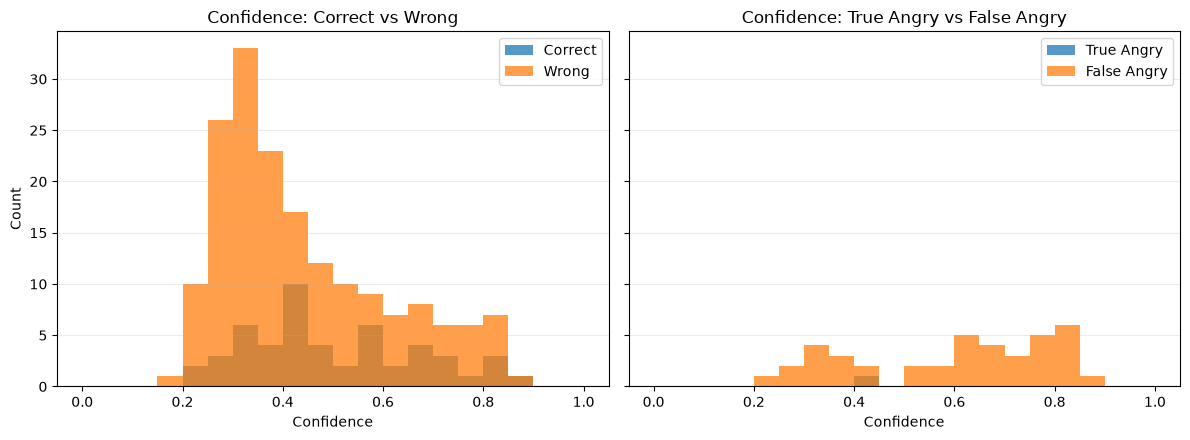

Over-confident on false Angry? True
Saved: reports/assets/audit_confidence_analysis.png


In [7]:
conf_df = audit_df.copy()
conf_df["confidence"] = pd.to_numeric(conf_df["confidence"], errors="coerce")
conf_df = conf_df.dropna(subset=["confidence", "gt_label", "model_label"])

correct_conf = conf_df.loc[conf_df["gt_label"] == conf_df["model_label"], "confidence"]
wrong_conf = conf_df.loc[conf_df["gt_label"] != conf_df["model_label"], "confidence"]

true_angry_conf = conf_df.loc[(conf_df["model_label"] == "Angry") & (conf_df["gt_label"] == "Angry"), "confidence"]
false_angry_conf = conf_df.loc[(conf_df["model_label"] == "Angry") & (conf_df["gt_label"] != "Angry"), "confidence"]

print("Mean confidence (correct):", round(correct_conf.mean(), 4) if len(correct_conf) else np.nan)
print("Mean confidence (wrong):", round(wrong_conf.mean(), 4) if len(wrong_conf) else np.nan)
print("Mean confidence (true Angry):", round(true_angry_conf.mean(), 4) if len(true_angry_conf) else np.nan)
print("Mean confidence (false Angry):", round(false_angry_conf.mean(), 4) if len(false_angry_conf) else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
bins = np.linspace(0, 1, 21)

axes[0].hist(correct_conf, bins=bins, alpha=0.75, label="Correct")
axes[0].hist(wrong_conf, bins=bins, alpha=0.75, label="Wrong")
axes[0].set_title("Confidence: Correct vs Wrong")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(true_angry_conf, bins=bins, alpha=0.75, label="True Angry")
axes[1].hist(false_angry_conf, bins=bins, alpha=0.75, label="False Angry")
axes[1].set_title("Confidence: True Angry vs False Angry")
axes[1].set_xlabel("Confidence")
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
conf_path = ASSET_DIR / "audit_confidence_analysis.png"
plt.savefig(conf_path, dpi=200, bbox_inches="tight")
plt.show()

if len(false_angry_conf) and len(true_angry_conf):
    overconfident = false_angry_conf.mean() > true_angry_conf.mean()
    print("Over-confident on false Angry?", overconfident)
else:
    print("Not enough Angry samples to conclude over-confidence.")

print("Saved:", conf_path)

## 7. Landmark Features vs Correctness

True Angry count with brow feature: 1
False Angry count with brow feature: 27
Mean brow_lowering (true Angry): 0.0377
Mean brow_lowering (false Angry): 0.1346


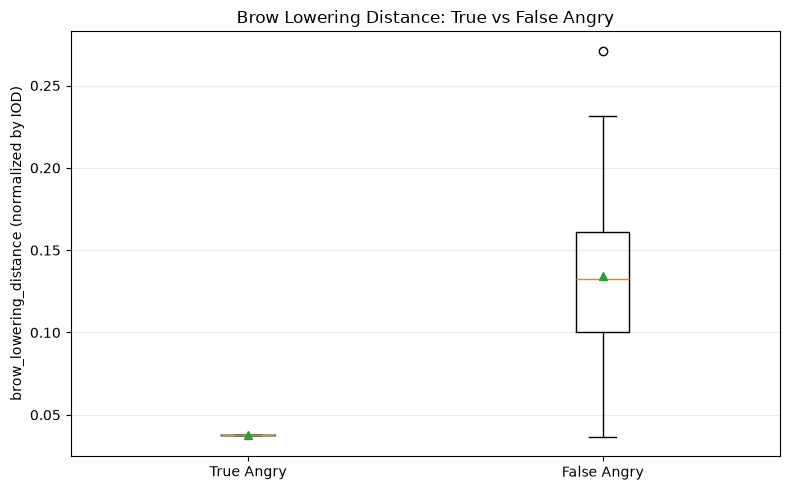

Saved: reports/assets/audit_brow_lowering_true_vs_false_angry.png
Hypothesis weak/unsupported in this sample: False Angry brow-lowering is not lower than True Angry.


In [8]:
lf_df = audit_df.copy()
lf_df["brow_lowering_distance"] = pd.to_numeric(lf_df.get("brow_lowering_distance"), errors="coerce")

true_angry_geom = lf_df[(lf_df["model_label"] == "Angry") & (lf_df["gt_label"] == "Angry")]
false_angry_geom = lf_df[(lf_df["model_label"] == "Angry") & (lf_df["gt_label"] != "Angry")]

true_brow = true_angry_geom["brow_lowering_distance"].dropna()
false_brow = false_angry_geom["brow_lowering_distance"].dropna()

print("True Angry count with brow feature:", len(true_brow))
print("False Angry count with brow feature:", len(false_brow))
print("Mean brow_lowering (true Angry):", round(true_brow.mean(), 4) if len(true_brow) else np.nan)
print("Mean brow_lowering (false Angry):", round(false_brow.mean(), 4) if len(false_brow) else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
data = [true_brow.values, false_brow.values]
labels_box = ["True Angry", "False Angry"]
try:
    ax.boxplot(data, tick_labels=labels_box, showmeans=True)
except TypeError:
    ax.boxplot(data, showmeans=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels_box)
ax.set_title("Brow Lowering Distance: True vs False Angry")
ax.set_ylabel("brow_lowering_distance (normalized by IOD)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
brow_path = ASSET_DIR / "audit_brow_lowering_true_vs_false_angry.png"
plt.savefig(brow_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", brow_path)

if len(true_brow) and len(false_brow):
    if false_brow.mean() < true_brow.mean():
        print("Hypothesis support: False Angry has lower brow-lowering, consistent with geometrically less-angry faces.")
    else:
        print("Hypothesis weak/unsupported in this sample: False Angry brow-lowering is not lower than True Angry.")

## 8. Summary Table

In [9]:
per_skin_summary = skin_acc.rename("accuracy").reset_index() if 'skin_acc' in globals() else pd.DataFrame(columns=["skin_tone", "accuracy"])

summary_rows = [
    {"metric": "overall_accuracy", "value": float(overall_accuracy)},
    {"metric": "error_rate", "value": float(error_rate)},
    {"metric": "false_angry_rate", "value": float(false_angry_rate) if not np.isnan(false_angry_rate) else np.nan},
    {"metric": "fairness_gap", "value": float(fairness_gap) if not np.isnan(fairness_gap) else np.nan},
]
summary_df = pd.DataFrame(summary_rows)
if not per_skin_summary.empty:
    per_skin_rows = per_skin_summary.assign(metric=per_skin_summary["skin_tone"].map(lambda x: f"accuracy_{x}"), value=per_skin_summary["accuracy"])[["metric", "value"]]
    summary_df = pd.concat([summary_df, per_skin_rows], ignore_index=True)

print("Summary table (thesis-ready):")
display(summary_df)

print("Per-skin-tone accuracy:")
display(per_skin_summary)

summary_path = Path("reports/audit_summary_metrics.csv")
per_skin_path = Path("reports/audit_per_skin_tone_accuracy.csv")
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(summary_path, index=False)
per_skin_summary.to_csv(per_skin_path, index=False)
print("Saved:", summary_path)
print("Saved:", per_skin_path)

Summary table (thesis-ready):


,metric,value
0,overall_accuracy,0.224670
1,error_rate,0.775330
2,false_angry_rate,0.176211
3,fairness_gap,0.297143
4,accuracy_Dark,0.440000
5,accuracy_Medium-Dark,0.142857


Per-skin-tone accuracy:


,skin_tone,accuracy
0,Dark,0.440000
1,Medium-Dark,0.142857


Saved: reports/audit_summary_metrics.csv
Saved: reports/audit_per_skin_tone_accuracy.csv
